In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-colorblind')
tf.random.set_seed(43)

In [3]:
#!wget https://www.dropbox.com/s/fxn3ldztzwxm0rw/FruitsData.zip

In [4]:
#!unzip -q "/content/FruitsData.zip"
import zipfile

with zipfile.ZipFile("FruitsData.zip", "r") as zip_ref:
    zip_ref.extractall()

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
tf.random.set_seed(4)

In [6]:
#create pathlib Path objects,
train_path=Path("fruits-360/Training")
test_path=Path("fruits-360/Test")

In [7]:
train_image_paths=train_path.glob("*/*.jpg")
test_image_paths=test_path.glob("*/*.jpg")

In [8]:
train_image_paths=list(train_image_paths)
train_image_paths=list(map(lambda x: str(x),train_image_paths))
train_labels=[i.split('/')[-2].strip().lower() for i in train_image_paths]
test_image_paths =list(test_image_paths)
test_image_paths=list(map(lambda x: str(x),test_image_paths))
test_labels=[i.split('/')[-2].strip().lower() for i in test_image_paths]

In [9]:
print(test_labels[::1_000])
print(train_labels[::1_000])

['apple braeburn', 'apple pink lady', 'apple red yellow 2', 'banana red', 'carambula', 'cherry wax black', 'corn', 'fig', 'grape white 2', 'hazelnut', 'lemon', 'mango red', 'nectarine flat', 'orange', 'pear', 'pear monster', 'pepper orange', 'physalis with husk', 'plum 3', 'potato white', 'strawberry wedge', 'tomato 2', 'tomato not ripened']
['apple braeburn', 'apple golden 1', 'apple golden 3', 'apple pink lady', 'apple red 2', 'apple red delicious', 'apple red yellow 2', 'avocado', 'banana', 'banana red', 'blueberry', 'cantaloupe 1', 'carambula', 'cherry 1', 'cherry 2', 'cherry wax black', 'cherry wax yellow', 'clementine', 'corn', 'cucumber ripe 2', 'eggplant', 'fig', 'grape blue', 'grape pink', 'grape white 2', 'grape white 4', 'grapefruit white', 'hazelnut', 'kaki', 'kohlrabi', 'lemon', 'limes', 'mandarine', 'mango red', 'melon piel de sapo', 'mulberry', 'nectarine flat', 'nut pecan', 'onion red peeled', 'orange', 'passion fruit', 'peach 2', 'pear', 'pear abate', 'pear forelle', '

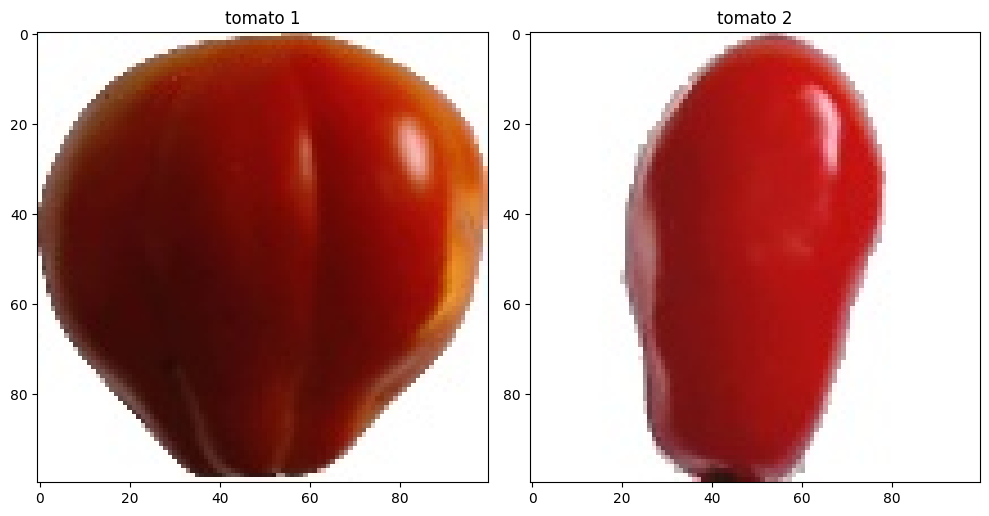

In [10]:
label_1,label_2='tomato 1','tomato 2'

p1=train_image_paths[train_labels.index(label_1)]
p2=test_image_paths[test_labels.index(label_2)]
plt.figure(figsize=(10,7))
plt.subplot(1,2,1)
plt.title(label_1)
plt.imshow(plt.imread(p1))
plt.subplot(1,2,2)
plt.title(label_2)
plt.imshow(plt.imread(p2))
plt.tight_layout()
plt.show()

In [11]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
train_image_labels=le.fit_transform(train_labels)
test_image_labels=le.transform(test_labels)

In [12]:
train_image_labels[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [13]:
train_image_labels=tf.keras.utils.to_categorical(train_image_labels)
test_image_labels=tf.keras.utils.to_categorical(test_image_labels)

In [14]:
train_image_labels[:1]

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]])

In [15]:
from sklearn.model_selection import train_test_split
Train_paths,Val_paths,Train_labels,Val_labels=train_test_split(train_image_paths,train_image_labels,test_size=0.2,random_state=43)

In [16]:
print(Train_paths[:10])
print(Train_labels[:10])

['fruits-360/Training/Kiwi/r_309_100.jpg', 'fruits-360/Training/Pepper Green/r_165_100.jpg', 'fruits-360/Training/Redcurrant/r_206_100.jpg', 'fruits-360/Training/Nectarine/2_100.jpg', 'fruits-360/Training/Avocado/28_100.jpg', 'fruits-360/Training/Walnut/r_166_100.jpg', 'fruits-360/Training/Avocado/r_156_100.jpg', 'fruits-360/Training/Cantaloupe 1/319_100.jpg', 'fruits-360/Training/Kumquats/r_243_100.jpg', 'fruits-360/Training/Chestnut/r2_53_100.jpg']
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [17]:
#libraries that load image paths as a vector of pixels: open cv,sk image, and python image library pil.
#this will use Tensorflow

In [18]:
#decode images
def decode_image(image,label):
  image=tf.io.read_file(image)
  image=tf.io.decode_jpeg(image,channels=3)
  return image,label

In [19]:
#use Sequential to process. It's very optimized
IMG_SIZE=224
BATCH_SIZE=32
resize=tf.keras.Sequential([tf.keras.layers.Resizing(IMG_SIZE,IMG_SIZE)])
data_augmentation=tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(height_factor=(-0.3,-0.2))])

I0000 00:00:1755780928.795122    2149 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3586 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [20]:
#Funtion to create a tensorflow data object
AUTOTUNE= tf.data.AUTOTUNE
def get_dataset(paths,labels,train=True):
  image_paths=tf.convert_to_tensor(paths)
  labels=tf.convert_to_tensor(labels)
  image_dataset=tf.data.Dataset.from_tensor_slices(image_paths)
  label_dataset= tf.data.Dataset.from_tensor_slices(labels)
  dataset=tf.data.Dataset.zip((image_dataset,label_dataset))
  dataset=dataset.map(lambda image,label: decode_image(image,label))
  dataset=dataset.map(lambda image,label: (resize(image),label))
  dataset=dataset.shuffle(1_000)
  dataset=dataset.batch(BATCH_SIZE)

  if train:
    dataset=dataset.map(lambda image,label:(data_augmentation(image),label),num_parallel_calls=AUTOTUNE)

  dataset=dataset.repeat()
  return dataset


In [21]:
%time train_dataset=get_dataset(Train_paths,Train_labels)
print(type(train_dataset))
image,label=next(iter(train_dataset))
print(image.shape)
print(label.shape)

CPU times: user 2.92 s, sys: 51.6 ms, total: 2.97 s
Wall time: 3.07 s
<class 'tensorflow.python.data.ops.repeat_op._RepeatDataset'>
(32, 224, 224, 3)
(32, 131)


In [22]:
%time val_dataset=get_dataset(Val_paths,Val_labels,train=False)
print(type(val_dataset))
val_image,val_label=next(iter(val_dataset))
print(val_image.shape)
print(val_label.shape)

CPU times: user 50.1 ms, sys: 3 ms, total: 53.1 ms
Wall time: 54.6 ms
<class 'tensorflow.python.data.ops.repeat_op._RepeatDataset'>
(32, 224, 224, 3)
(32, 131)


In [ ]:
from tensorflow.keras.applications import EfficientNetB3
backbone=EfficientNetB3(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights=None)
model = tf.keras.Sequential([
    backbone,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(len(le.classes_), activation='softmax')
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 131)            │       201,347 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,984,882 (41.90 MB)

 Trainable params: 10,897,579 (41.57 MB)

 Non-trainable params: 87,303 (341.03 KB)

In [27]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999,
                                                        epsilon=1e-07),
                     loss='categorical_crossentropy',
                     metrics=['accuracy',tf.keras.metrics.Precision(name='precision'),
                              tf.keras.metrics.Recall(name='recall')])

In [28]:
history=model.fit(
    train_dataset,
    steps_per_epoch=len(Train_paths)//BATCH_SIZE,
    epochs=1,
    validation_data=val_dataset,
    validation_steps=len(Val_paths)//BATCH_SIZE)

2025-08-21 08:29:40.505406: I external/local_xla/xla/service/service.cc:163] XLA service 0x726310004250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-08-21 08:29:40.505563: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2025-08-21 08:29:42.986151: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-08-21 08:29:53.925035: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91200
2025-08-21 08:30:03.686458: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-08-21 08:30:06.

1692/1692 ━━━━━━━━━━━━━━━━━━━━ 1526s 741ms/step - accuracy: 0.6449 - loss: 1.2862 - precision: 0.8632 - recall: 0.5509 - val_accuracy: 0.5296 - val_loss: 2.4587 - val_precision: 0.5851 - val_recall: 0.5014


In [29]:
#turn off backbone
model.layers[0].trainable=False

In [30]:
#define callbacks
checkpoint=tf.keras.callbacks.ModelCheckpoint("efficientnetb3.weights.h5",verbose=1,save_best_only=True,save_weights_only=True)
early_stop=tf.keras.callbacks.EarlyStopping(patience=4)
plateau=tf.keras.callbacks.ReduceLROnPlateau(patience=3,monitor='val_loss',factor=0.02)

In [31]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 131)            │       201,347 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,780,042 (125.05 MB)

 Trainable params: 201,347 (786.51 KB)

 Non-trainable params: 10,783,535 (41.14 MB)

 Optimizer params: 21,795,160 (83.14 MB)

In [32]:
history = model.fit(train_dataset,
                           steps_per_epoch=len(Train_paths)//BATCH_SIZE,
                           epochs=8,
                           callbacks=[checkpoint,early_stop,plateau],
                           validation_data=val_dataset,
                           validation_steps=len(Val_paths)//BATCH_SIZE)


Epoch 1/8
1692/1692 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.9281 - loss: 0.2253 - precision: 0.9425 - recall: 0.9148
Epoch 1: val_loss improved from None to 1.34440, saving model to efficientnetb3.weights.h5
1692/1692 ━━━━━━━━━━━━━━━━━━━━ 939s 553ms/step - accuracy: 0.9393 - loss: 0.1899 - precision: 0.9504 - recall: 0.9291 - val_accuracy: 0.6687 - val_loss: 1.3444 - val_precision: 0.6993 - val_recall: 0.6338 - learning_rate: 0.0010
Epoch 2/8


2025-08-21 09:09:57.956723: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-08-21 09:09:58.180430: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-08-21 09:09:59.050102: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-08-21 09:09:59.355979: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-08-21 09:09:59.653439: E external/local_xla/xla/stream_

1692/1692 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.9596 - loss: 0.1290 - precision: 0.9644 - recall: 0.9537
Epoch 2: val_loss did not improve from 1.34440
1692/1692 ━━━━━━━━━━━━━━━━━━━━ 499s 256ms/step - accuracy: 0.9642 - loss: 0.1102 - precision: 0.9684 - recall: 0.9601 - val_accuracy: 0.6421 - val_loss: 1.7111 - val_precision: 0.6753 - val_recall: 0.6175 - learning_rate: 0.0010
Epoch 3/8
1692/1692 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.9658 - loss: 0.1042 - precision: 0.9697 - recall: 0.9629
Epoch 3: val_loss did not improve from 1.34440
1692/1692 ━━━━━━━━━━━━━━━━━━━━ 438s 259ms/step - accuracy: 0.9722 - loss: 0.0857 - precision: 0.9752 - recall: 0.9699 - val_accuracy: 0.6640 - val_loss: 1.7824 - val_precision: 0.6893 - val_recall: 0.6491 - learning_rate: 0.0010
Epoch 4/8
1692/1692 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.9771 - loss: 0.0774 - precision: 0.9791 - recall: 0.9748
Epoch 4: val_loss did not improve from 1.34440
1692/1692 ━━━━━━━━━━━━━━━━━━━━ 43

In [35]:
model.load_weights('efficientnetb3.weights.h5')

In [ ]:
test_image_labels=tf.convert_to_tensor(test_image_labels)
test_image_paths=tf.convert_to_tensor(test_image_paths)

In [42]:
def decode_test_images(image,label):
    image=tf.io.read_file(image)
    image=tf.io.decode_jpeg(image,channels=3)
    image=tf.image.resize(image,[IMG_SIZE,IMG_SIZE],method='bilinear')
    return image,label

In [48]:
test_dataset=(tf.data.Dataset
    .from_tensor_slices((test_image_paths,test_image_labels))
    .map(decode_test_images)
    .batch(BATCH_SIZE))

In [53]:
image,label=next(iter(test_dataset))
print(image.shape)
print(label.shape)

(32, 224, 224, 3)
(32, 131)


apple braeburn


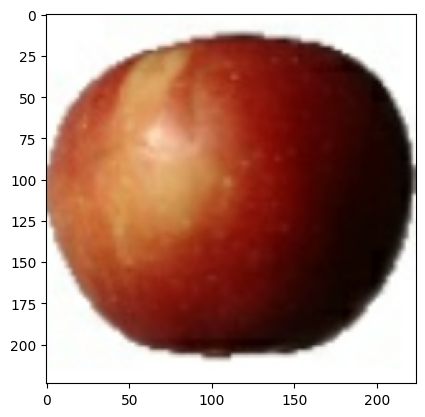

In [56]:
print(le.inverse_transform(np.argmax(label,axis=1))[0])
plt.imshow((image[0].numpy()/255).reshape(IMG_SIZE,IMG_SIZE,3))

In [58]:
loss,acc,prec,rec=model.evaluate(test_dataset)
print(" Testing Acc: ",acc)
print(" Testing Precision: ",prec)
print(" Testing Recall: ",rec)
print(" Testing Loss: ",loss)

709/709 ━━━━━━━━━━━━━━━━━━━━ 40s 55ms/step - accuracy: 0.8013 - loss: 0.8121 - precision: 0.8165 - recall: 0.7894
 Testing Acc:  0.8013487458229065
 Testing Precision:  0.8164660930633545
 Testing Recall:  0.7894040942192078
 Testing Loss:  0.8121442794799805


In [60]:
def loadimage(image_path):
    image=tf.io.read_file(image_path)
    image=tf.io.decode_jpeg(image,channels=3)
    image=tf.image.resize(image,[IMG_SIZE,IMG_SIZE],method="bilinear")
    plt.imshow(image.numpy()/255)
    image=tf.expand_dims(image,0)
    return image

In [70]:
def realtimepred(image_path,model,encoder_):
    image=loadimage(image_path)
    prediction=model.predict(image)
    prediction=np.argmax(prediction,axis=1)
    return encoder_.inverse_transform(prediction)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


np.str_('avocado ripe')

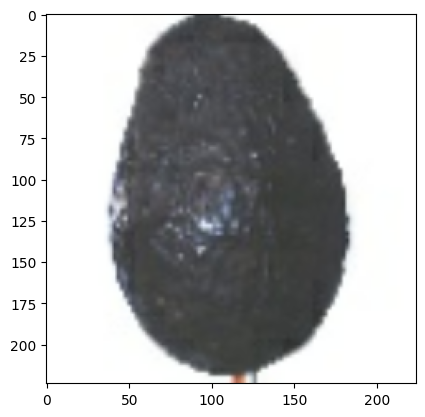

In [71]:
realtimepred('fruits-360/Test/Avocado ripe/96_100.jpg',model,le)